# Code

In [1]:
import os

In [2]:
os.chdir('..')

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data/raw/employment.csv')

In [5]:
df.shape

(73462, 15)

In [8]:
df.head(5)

,Unnamed: 0,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0
1,1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482.0,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290.0,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135.0,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932.0,C++;Python,2,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73462 entries, 0 to 73461
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      73462 non-null  int64  
 1   Age             73462 non-null  str    
 2   Accessibility   73462 non-null  str    
 3   EdLevel         73462 non-null  str    
 4   Employment      73462 non-null  int64  
 5   Gender          73462 non-null  str    
 6   MentalHealth    73462 non-null  str    
 7   MainBranch      73462 non-null  str    
 8   YearsCode       73462 non-null  int64  
 9   YearsCodePro    73462 non-null  int64  
 10  Country         73462 non-null  str    
 11  PreviousSalary  73462 non-null  float64
 12  HaveWorkedWith  73399 non-null  str    
 13  ComputerSkills  73462 non-null  int64  
 14  Employed        73462 non-null  int64  
dtypes: float64(1), int64(6), str(8)
memory usage: 8.4 MB


Unnamed

Age is string

HaveWorkedWith should be split

In [9]:
df.isna().any()

Unnamed: 0        False
Age               False
Accessibility     False
EdLevel           False
Employment        False
Gender            False
MentalHealth      False
MainBranch        False
YearsCode         False
YearsCodePro      False
Country           False
PreviousSalary    False
HaveWorkedWith     True
ComputerSkills    False
Employed          False
dtype: bool

In [10]:
df['HaveWorkedWith'].isna().sum()

np.int64(63)

63 missing values in HaveWorkedWith

In [20]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [22]:
df.duplicated().any()

np.True_

Even if there are duplicates, it won't because there are no unique columns

In [31]:
df.head(1)

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0


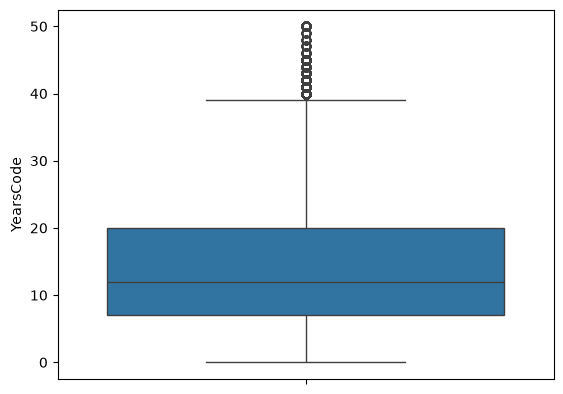

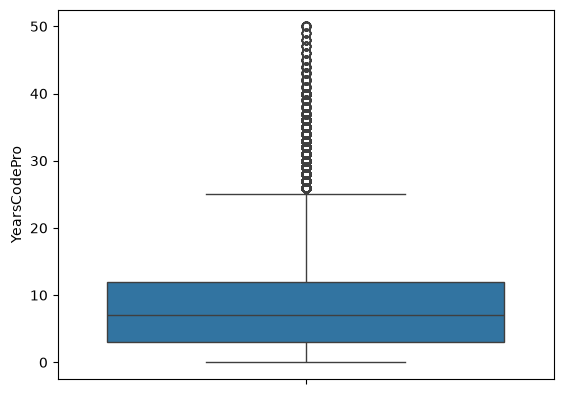

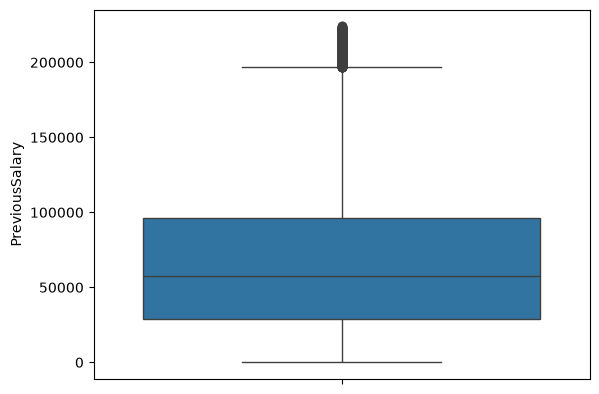

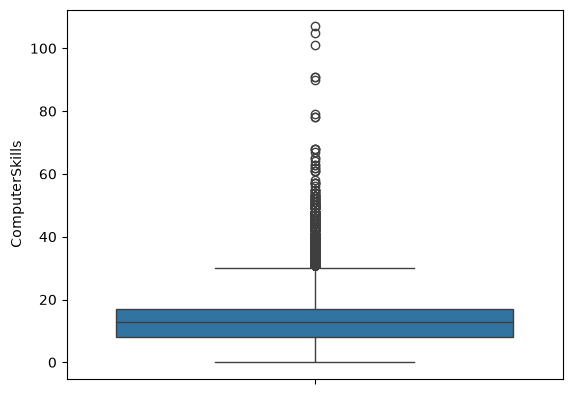

In [36]:
for col in ['YearsCode', 'YearsCodePro', 'PreviousSalary', 'ComputerSkills']:
    sns.boxplot(df[col])
    plt.show()

YearsCode, YearsCodePro, PreviousSalary, ComputerSkills contain outliers.

In [38]:
for col in ['YearsCode', 'YearsCodePro', 'PreviousSalary', 'ComputerSkills']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LB = Q1 - (IQR * 1.5)
    UB = Q3 + (IQR * 1.5)
    upper_outliers = (df[col] > UB).sum()
    lower_outliers = (df[col] < LB).sum()
    print("Upper Outliers In", col, ":", upper_outliers)

Upper Outliers In YearsCode : 1809
Upper Outliers In YearsCodePro : 3353
Upper Outliers In PreviousSalary : 1479
Upper Outliers In ComputerSkills : 1633


In [39]:
df.describe()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed
count,73462.000000,73462.000000,73462.000000,73462.000000,73462.000000,73462.000000
mean,0.883096,14.218902,9.098377,67750.260611,13.428221,0.536223
std,0.321308,9.405172,7.960201,49488.142118,7.057835,0.498690
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,7.000000,3.000000,28839.000000,8.000000,0.000000
50%,1.000000,12.000000,7.000000,57588.000000,13.000000,1.000000
75%,1.000000,20.000000,12.000000,95979.000000,17.000000,1.000000
max,1.000000,50.000000,50.000000,224000.000000,107.000000,1.000000


In [48]:
df.describe(include='all')

,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
count,73462,73462,73462,73462.000000,73462,73462,73462,73462.000000,73462.000000,73462,73462.000000,73399,73462.000000,73462.000000
unique,2,2,5,NaN,3,2,2,NaN,NaN,172,NaN,69980,NaN,NaN
top,<35,No,Undergraduate,NaN,Man,No,Dev,NaN,NaN,United States of America,NaN,Python,NaN,NaN
freq,47819,71355,37402,NaN,68573,56944,67396,NaN,NaN,14696,NaN,71,NaN,NaN
mean,NaN,NaN,NaN,0.883096,NaN,NaN,NaN,14.218902,9.098377,NaN,67750.260611,NaN,13.428221,0.536223
std,NaN,NaN,NaN,0.321308,NaN,NaN,NaN,9.405172,7.960201,NaN,49488.142118,NaN,7.057835,0.498690
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,7.000000,3.000000,NaN,28839.000000,NaN,8.000000,0.000000
50%,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,12.000000,7.000000,NaN,57588.000000,NaN,13.000000,1.000000
75%,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,20.000000,12.000000,NaN,95979.000000,NaN,17.000000,1.000000


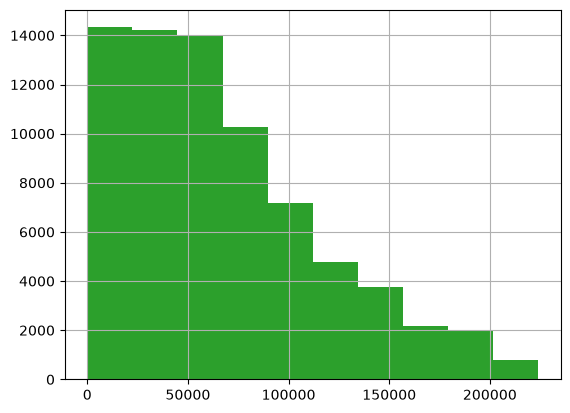

In [42]:
plt.hist(df['PreviousSalary'])
plt.show()

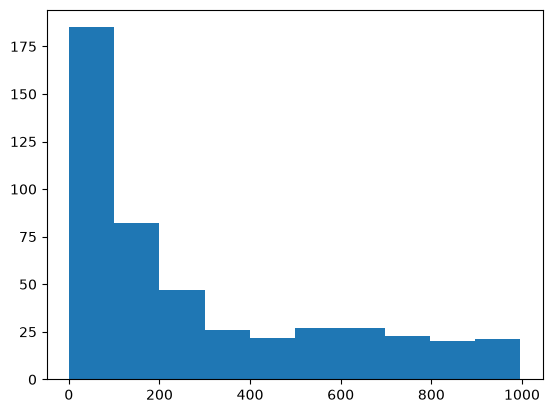

In [47]:
plt.hist(df[df['PreviousSalary'] < 1000]['PreviousSalary'])
plt.show()

# Conclusions

Dataset contains 73,462 rows and 15 columns.

Column named "Unnamed: 0".

Age is string.

HaveWorkedWith should be split.

4 rows were shown to be duplicated but when printed they weren't duplicates.

Computer Skills can be 0.

There are 5 education levels.

Age is either > or < 35.

There weren't any lower outliers.

Upper Outliers In YearsCode : 1809\
Upper Outliers In YearsCodePro : 3353\
Upper Outliers In PreviousSalary : 1479\
Upper Outliers In ComputerSkills : 1633